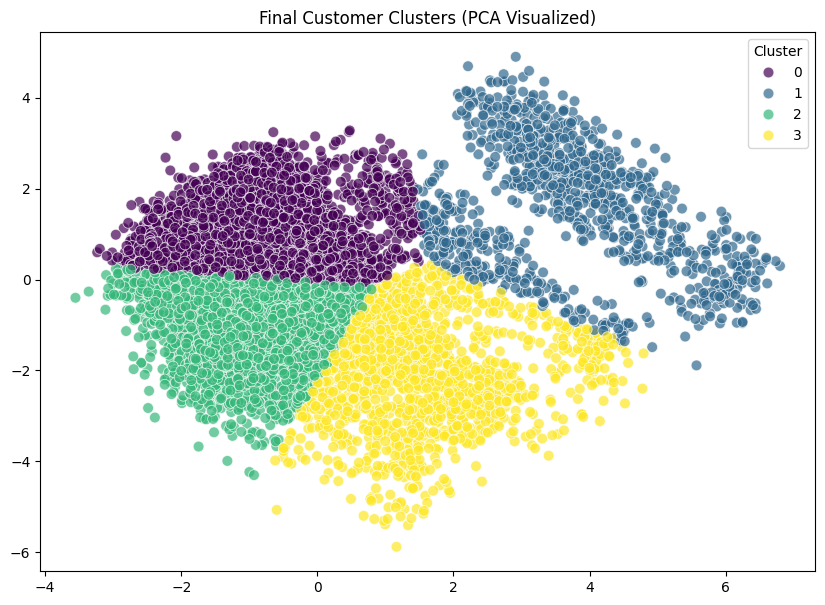

✅ 클러스터링 완료 및 최종 파일 저장: df_with_clusters.csv


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:

# 1. 인코딩된 데이터 불러오기
df_ready = pd.read_csv('./data/df_encoded_final.csv')

In [ ]:
# 2. 전처리: 숫자형 데이터만 스케일링 (StandardScaler)
# bool 타입 등으로 변환된 원핫 컬럼들도 숫자로 처리됩니다.
X = df_ready.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3. PCA 차원 축소 (2차원으로 압축하여 시각화 대비)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:

# 4. K-Means 클러스터링 (Elbow Method 기반 최적 k=4 가정)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ready['Cluster'] = kmeans.fit_predict(X_pca)

In [ ]:
# 5. [시각화] PCA 군집 결과 확인
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_ready['Cluster'], 
                palette='viridis', s=60, alpha=0.7)
plt.title('Final Customer Clusters (PCA Visualized)')
plt.show()

In [ ]:

# 6. 최종 결과 저장 (군집 ID가 포함된 데이터)
df_ready.to_csv('./data/df_with_clusters.csv', index=False)
print("✅ 클러스터링 완료 및 최종 파일 저장: df_with_clusters.csv")